# MMM Calibration with PyMC-Marketing Lift Tests

Marketing mix models fit on observational spend history inherit its biases: when
search budgets chase demand, the model credits search with sales that demand would
have produced anyway. A geo experiment breaks that circularity - and diff-diff's
MMM exporters carry the experiment's result into
[PyMC-Marketing](https://www.pymc-marketing.io/) as a *lift test* with one function
call.

This tutorial runs the full pipeline **end-to-end with the real frameworks**:

1. simulate a geo-week world where search spend chased demand historically, then a
   staggered geo **spend-boost experiment** was run under a budget freeze;
2. measure the boost's incremental sales with `CallawaySantAnna` -
   `results.aggregate('total')` for the campaign headline, and
   `results.aggregate('simple')` for the per-geo-week ATT the lift row needs;
3. export the measurement with `to_pymc_marketing_lift_test` via the container
   route - the only number you supply is the count of treated geos (the
   grain-reconciliation `scale`);
4. fit the national PyMC-Marketing MMM **without and with** the lift test and watch
   the search-ROI posterior move to the truth and tighten.

**Requirements.** This notebook needs `pymc-marketing==1.0.0` (Python 3.12), which
is *not* a diff-diff dependency: `pip install "pymc-marketing==1.0.0" diff-diff`.
It cannot share an environment with the Meridian tutorial (notebook 30) - the two
frameworks pin incompatible `arviz` ranges - so each tutorial gets its own
environment/kernel. Runtime is a few minutes (two small MCMC fits).

**Reproducibility.** MCMC draws depend on framework and transitive-dependency
versions and on the platform. The committed outputs were produced with
pymc-marketing 1.0.0; re-executing under other versions may shift posterior
numbers. The `assert` cells check the qualitative claims (sampler health, and
that calibration moves the posterior toward the simulated truth and tightens it)
with slack margins - if one trips on your machine, it means exactly that claim
did not reproduce in your environment.

## A world where spend chased demand

Fifteen geos, 104 weeks, two channels. The **search** channel is the experiment
channel and is deliberately simple: zero carryover (an immediate-response channel)
and a *linear* true response - every search dollar returns `BETA_SEARCH = 2.0`
dollars of sales, so the true incremental ROI is 2.0 by construction. The **tv**
channel keeps adstock and saturation for realism.

The bias mechanism: for the first 52 weeks, search budgets *chased seasonal
demand* (`spend = base * (1 + 0.5 * season)` while the same season moves sales
directly). From week 52 budgets were **frozen** - standard geo-test hygiene, and
what makes the lift test's baseline spend `x` a single well-defined number - and
from week 60 a staggered boost of \$50/week rolled out across nine treated geos
(cohorts at weeks 60, 68, 76), leaving six geos as controls.

In [1]:
import warnings

# Scoped suppressions only: framework-churn warnings are hidden, but estimator
# UserWarnings (diff-diff's loud-failure channel) stay visible.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from diff_diff import CallawaySantAnna, ImputationDiD
from diff_diff.mmm import to_pymc_marketing_lift_test

SEED = 2026
N_GEOS, N_WEEKS = 15, 104
BETA_SEARCH = 2.0        # true incremental sales per search dollar (the ROI truth)
SEARCH_BASE = 100.0      # baseline weekly search spend per geo (frozen in-test)
BOOST = 50.0             # constant weekly boost per treated geo
FREEZE_WEEK = 52         # budgets frozen from here (test hygiene)
TREAT_COHORTS = {60: [0, 1, 2], 68: [3, 4, 5], 76: [6, 7, 8]}
DEMAND_AMP = 300.0       # seasonal demand amplitude (sales units per geo)
CHASE = 0.5              # how strongly historical spend chased demand
TV_BASE, TV_BETA, TV_ADSTOCK, TV_SAT = 200.0, 600.0, 0.5, 0.004
BASE_SALES, GEO_SD, NOISE_SD = 3000.0, 100.0, 15.0

rng = np.random.default_rng(SEED)
geo_start = {g: w for w, gg in TREAT_COHORTS.items() for g in gg}
G_TREATED = len(geo_start)

season = np.sin(2 * np.pi * np.arange(N_WEEKS) / 52.0)  # common to all geos

rows = []
for g in range(N_GEOS):
    tv = TV_BASE * (1 + 0.1 * rng.random(N_WEEKS))
    ad = np.zeros(N_WEEKS)
    carry = 0.0
    for t in range(N_WEEKS):
        carry = tv[t] + TV_ADSTOCK * carry   # tv keeps adstock ...
        ad[t] = carry
    tvc = TV_BETA * (1 - np.exp(-TV_SAT * ad))  # ... and saturation
    geo_level = rng.normal(0, GEO_SD)
    for t in range(N_WEEKS):
        if t < FREEZE_WEEK:
            search = SEARCH_BASE * (1 + CHASE * season[t])  # demand-chasing history
        else:
            boosted = g in geo_start and t >= geo_start[g]
            search = SEARCH_BASE + (BOOST if boosted else 0.0)  # frozen + boost
        sales = (
            BASE_SALES + geo_level + DEMAND_AMP * season[t]
            + BETA_SEARCH * search               # linear, zero carryover
            + tvc[t] + rng.normal(0, NOISE_SD)
        )
        rows.append((g, t, sales, search, tv[t], geo_start.get(g, 0)))

panel = pd.DataFrame(
    rows, columns=["geo", "week", "sales", "search_spend", "tv_spend", "first_treat"]
)
panel.head()

,geo,week,sales,search_spend,tv_spend,first_treat
0,0,0,3543.352739,100.000000,203.578696,60
1,0,1,3687.103795,106.026834,212.798263,60
2,0,2,3753.001771,111.965783,209.345368,60
3,0,3,3840.767622,117.730244,207.410011,60
4,0,4,3905.212324,123.236159,207.098347,60


## Measure the experiment with staggered DiD

`CallawaySantAnna` handles the staggered rollout; `aggregate('total')` turns the
per-geo-week ATT into the campaign's **total incremental sales** - the estimator's
own finite-masked aggregation mass, no hand-counting. As a robustness habit we
cross-check the total with `ImputationDiD`, and we verify the total's mass against
a raw-frame count.

In [2]:
res = CallawaySantAnna().fit(
    panel, outcome="sales", unit="geo", time="week", first_treat="first_treat"
)
simple = res.aggregate("simple")
total = res.aggregate("total")

imp_total = (
    ImputationDiD()
    .fit(panel, outcome="sales", unit="geo", time="week", first_treat="first_treat")
    .aggregate("total")
)

# The total's n is the treated geo-week mass - pin it against the raw frame.
frame_mass = int(((panel.first_treat > 0) & (panel.week >= panel.first_treat)).sum())
assert total.n[0] == frame_mass

boost_spend_total = BOOST * frame_mass
true_total = BETA_SEARCH * boost_spend_total

print(f"per-geo-week ATT: {res.overall_att:.2f} (se {res.overall_se:.2f}; truth {BETA_SEARCH * BOOST:.0f})")
print(f"CS total incremental sales:        {total.att[0]:,.0f}")
print(f"ImputationDiD total (cross-check): {imp_total.att[0]:,.0f}")
print(f"simulated truth:                   {true_total:,.0f}")

per-geo-week ATT: 103.64 (se 9.17; truth 100)
CS total incremental sales:        33,579
ImputationDiD total (cross-check): 33,217
simulated truth:                   32,400


## Export the lift test - grain reconciliation

PyMC-Marketing scores a lift-test row against
`saturation(x + delta_x) - saturation(x)`: **every field must describe the same
observation** - same channel, same population, same period span - at the grain the
MMM models. Our MMM below is *national-weekly*, so the row must be too:

- `x` - pre-boost national weekly search spend (`SEARCH_BASE * N_GEOS`; well
  defined because budgets were frozen),
- `delta_x` - the summed weekly boost across treated geos (`BOOST * G_TREATED`),
- `delta_y` - the *weekly national* incremental: the per-geo-week ATT times the
  number of treated geos.

That last product is exactly what the container route computes:
`aggregation_result=res.aggregate('simple'), scale=G_TREATED` - the scale is the
number of treated geos per week, a physical quantity, not a fudge factor.

Two practice notes. With a *carryover* channel you would restrict the aggregation
to post-ramp horizons before exporting. And mind the staggered rollout: national
spend moved through two intermediate levels (\$1,650 and \$1,800) before reaching
\$1,950, so averaging the per-geo-week ATT across those regimes and pairing it
with the single `1500 -> 1950` transition is exact **here only because this
simulation's response is linear and homogeneous** (the DGP pins above). With a
real, possibly *saturating* channel, align the lift row with one actual spend
transition instead: either boost all test geos simultaneously (the cleaner
design for lift-test export), or keep the FULL panel in the estimator fit -
Callaway-Sant'Anna needs every cohort's pre-treatment baseline - and restrict
only the post-fit aggregation to the full-rollout calendar periods (for
example, average the `aggregate('calendar')` rows for the weeks where all
treated geos are boosted), so `delta_y` describes the same
`x -> x + delta_x` step the row claims.

In [3]:
x_national = SEARCH_BASE * N_GEOS
delta_x_national = BOOST * G_TREATED

df_lift = to_pymc_marketing_lift_test(
    channel="search",
    x=x_national,
    delta_x=delta_x_national,
    aggregation_result=simple,
    scale=G_TREATED,
)
df_lift

,channel,x,delta_x,delta_y,sigma
0,search,1500.0,450.0,932.760714,82.569488


In [4]:
# Guardrail: a 'total' container is already in outcome units - passing any scale
# with it would double-count, and the exporter refuses loudly.
try:
    to_pymc_marketing_lift_test(
        channel="search", x=x_national, delta_x=delta_x_national,
        aggregation_result=total, scale=1.0,
    )
except ValueError as err:
    print(f"ValueError: {err}")

ValueError: scale is not accepted with a level='total' container: this container's rows are already totals; scale would double-count - pass the container alone (aggregate('total') already applied the estimator's own finite-masked aggregation mass)


## Fit the national MMM - without and with the lift test

The MMM sees only the national weekly series, where the demand-chasing history
lives. We fit the same model twice: once on the observational data alone, once
after `add_lift_test_measurements(df_lift)`. The
`add_original_scale_contribution_variable` call (before sampling) exposes the
channel-contribution posterior in original sales units, which we need to read the
ROI back out.

In [5]:
nat = panel.groupby("week").agg(
    sales=("sales", "sum"), search=("search_spend", "sum"), tv=("tv_spend", "sum")
).reset_index()
nat["date"] = pd.date_range("2024-01-01", periods=N_WEEKS, freq="W-MON")
X = nat[["date", "search", "tv"]]
y = nat["sales"].rename("y")

# Counterfactual spend path with the boost removed (for the ROI readout below).
X_cf = X.copy()
X_cf.loc[X_cf.index >= FREEZE_WEEK, "search"] = x_national

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation


def fit_mmm(lift=None):
    m = MMM(
        date_column="date",
        channel_columns=["search", "tv"],
        adstock=GeometricAdstock(l_max=4),
        saturation=LogisticSaturation(),
    )
    m.build_model(X, y)
    m.add_original_scale_contribution_variable(var=["channel_contribution"])
    if lift is not None:
        m.add_lift_test_measurements(lift)
    m.fit(X, y, chains=4, draws=500, tune=3000, progressbar=False,
          random_seed=SEED, target_accept=0.999,
          nuts_sampler_kwargs={"max_treedepth": 14})
    return m


mmm_plain = fit_mmm()
mmm_cal = fit_mmm(df_lift)
print("both fits done")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [adstock_alpha, saturation_lam, saturation_beta, y_sigma, intercept_contribution]


Sampling 4 chains for 3_000 tune and 500 draw iterations (12_000 + 2_000 draws total) took 179 seconds.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [adstock_alpha, saturation_lam, saturation_beta, y_sigma, intercept_contribution]


Sampling 4 chains for 3_000 tune and 500 draw iterations (12_000 + 2_000 draws total) took 175 seconds.


both fits done


## Read out the campaign ROI posterior

The estimand mirrors the experiment exactly: the model-implied **incremental sales
of the boost campaign** - per-draw channel contributions at the observed spend
minus contributions with the boost removed - divided by the boost spend. For this
linear world the truth is `BETA_SEARCH = 2.0`.

In [6]:
def campaign_roi(m):
    def contrib(Xd):
        ds = m.sample_posterior_predictive(
            Xd, extend_idata=False, combined=False, progressbar=False,
            var_names=["channel_contribution_original_scale"], random_seed=SEED,
        )
        return ds["channel_contribution_original_scale"].sel(channel="search").sum("date")

    # keeps (chain, draw) dims so ArviZ diagnostics below are chain-aware
    return (contrib(X) - contrib(X_cf)) / boost_spend_total


roi_plain = campaign_roi(mmm_plain)
roi_cal = campaign_roi(mmm_cal)

for name, roi in [("without lift test", roi_plain), ("with lift test", roi_cal)]:
    flat = np.asarray(roi).ravel()
    lo, hi = np.quantile(flat, [0.05, 0.95])
    print(f"{name:>18}: ROI mean {flat.mean():.2f}, 90% interval ({lo:.2f}, {hi:.2f})")
print(f"{'truth':>18}: {BETA_SEARCH:.2f}")
print(f"{'DiD measurement':>18}: {df_lift.delta_y[0] / df_lift.delta_x[0]:.2f} "
      f"± {df_lift.sigma[0] / df_lift.delta_x[0]:.2f}")

Sampling: []


Sampling: []


Sampling: []


Sampling: []


 without lift test: ROI mean 3.52, 90% interval (1.78, 5.36)
    with lift test: ROI mean 2.21, 90% interval (1.91, 2.50)
             truth: 2.00
   DiD measurement: 2.07 ± 0.18


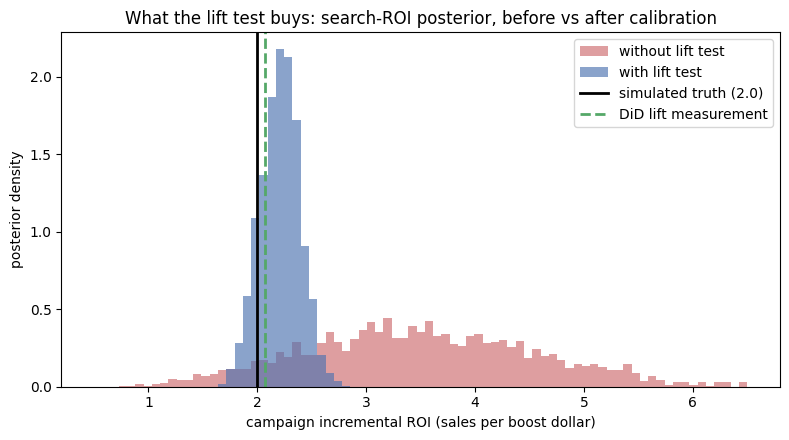

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0.5, 6.5, 80)
ax.hist(np.asarray(roi_plain).ravel(), bins=bins, density=True, alpha=0.55,
        label="without lift test", color="#c44e52")
ax.hist(np.asarray(roi_cal).ravel(), bins=bins, density=True, alpha=0.65,
        label="with lift test", color="#4c72b0")
ax.axvline(BETA_SEARCH, color="black", lw=2, label="simulated truth (2.0)")
did_roi = df_lift.delta_y[0] / df_lift.delta_x[0]
ax.axvline(did_roi, color="#55a868", lw=2, ls="--", label="DiD lift measurement")
ax.set_xlabel("campaign incremental ROI (sales per boost dollar)")
ax.set_ylabel("posterior density")
ax.set_title("What the lift test buys: search-ROI posterior, before vs after calibration")
ax.legend()
plt.tight_layout()
plt.show()

The uncalibrated posterior is wide and biased high - the model still credits
search with demand it chased historically. The calibrated posterior concentrates
near the truth: the lift likelihood anchors the response curve at the one spend
change we actually experimented on.

## Acceptance checks

Hard checks on the claims this notebook makes: sampler health first, then the
calibration claims with slack margins against draw noise. The saturation
parameters sit on a ridge (`beta` and `lam` trade off along the fitted curve), so
the demanding sampler settings above (`target_accept=0.999`, deeper trees, long
tuning) are what it takes to traverse that geometry cleanly - with them, BOTH fits
sample with zero divergences, zero maximum-tree-depth events, and whole-model
maximum R-hat under PyMC's own 1.01 warning bar, so the wide uncalibrated
posterior is a faithful picture of the model's uncertainty rather than a sampling
artifact. ArviZ's chain-aware `az.rhat` and bulk/tail `az.ess` are additionally
checked on the derived campaign-ROI posterior - the quantity the notebook
reports.

In [8]:
import arviz as az

ess_floors = {"plain": 300, "calibrated": 800}
for name, m, roi in [("plain", mmm_plain, roi_plain), ("calibrated", mmm_cal, roi_cal)]:
    div = int(m.idata.sample_stats["diverging"].sum())
    mtd = int(m.idata.sample_stats["reached_max_treedepth"].sum())
    with warnings.catch_warnings():
        # constant/deterministic posterior variables have undefined R-hat;
        # arviz emits RuntimeWarnings computing them - excluded below.
        warnings.simplefilter("ignore", RuntimeWarning)
        rh_all = az.rhat(m.idata.posterior)
    finite_rhats = np.concatenate(
        [np.asarray(rh_all[v]).ravel() for v in rh_all.data_vars]
    )
    max_rhat_model = float(finite_rhats[np.isfinite(finite_rhats)].max())
    rhat_roi = float(az.rhat(roi).values)
    ess_bulk = float(az.ess(roi).values)
    ess_tail = float(az.ess(roi, method="tail").values)
    print(f"{name}: divergences={div}, treedepth events={mtd}, "
          f"whole-model max Rhat={max_rhat_model:.4f}, "
          f"Rhat(campaign ROI)={rhat_roi:.4f}, ESS bulk={ess_bulk:.0f} tail={ess_tail:.0f}")
    assert div == 0, f"{name} fit: {div} divergences - sampling is unhealthy here"
    assert mtd == 0, f"{name} fit: {mtd} maximum-tree-depth events - raise max_treedepth"
    assert max_rhat_model < 1.01, (
        f"{name} fit: some model parameter has not converged (max Rhat {max_rhat_model:.4f})"
    )
    assert rhat_roi < 1.01, f"{name} fit: campaign-ROI chains disagree (Rhat {rhat_roi:.4f})"
    assert ess_bulk >= ess_floors[name], (
        f"{name} fit: campaign-ROI bulk ESS too low ({ess_bulk:.0f})"
    )
    assert ess_tail >= 300, f"{name} fit: campaign-ROI tail ESS too low ({ess_tail:.0f})"

flat_plain = np.asarray(roi_plain).ravel()
flat_cal = np.asarray(roi_cal).ravel()
err_plain = abs(float(flat_plain.mean()) - BETA_SEARCH)
err_cal = abs(float(flat_cal.mean()) - BETA_SEARCH)
width_plain = float(np.quantile(flat_plain, 0.95) - np.quantile(flat_plain, 0.05))
width_cal = float(np.quantile(flat_cal, 0.95) - np.quantile(flat_cal, 0.05))
print(f"error: {err_plain:.2f} -> {err_cal:.2f}; 90% width: {width_plain:.2f} -> {width_cal:.2f}")

assert err_cal < err_plain, (
    "calibrated ROI mean is not closer to the simulated truth - the lift test did "
    "not correct the bias in this environment"
)
assert width_cal < 0.8 * width_plain, (
    "calibrated 90% interval is not clearly narrower - the lift test did not add "
    "information in this environment"
)
print("all acceptance checks passed")

plain: divergences=0, treedepth events=0, whole-model max Rhat=1.0069, Rhat(campaign ROI)=1.0016, ESS bulk=458 tail=366
calibrated: divergences=0, treedepth events=0, whole-model max Rhat=1.0062, Rhat(campaign ROI)=1.0014, ESS bulk=2104 tail=1197
error: 1.52 -> 0.21; 90% width: 3.59 -> 0.59
all acceptance checks passed


## Where to go next

- **Meridian**: notebook 30 runs the same hand-off into Google Meridian's ROI
  priors, using a geo-holdout *launch* experiment (the other classic design) and
  `to_meridian_roi_prior` + `meridian_calibration_mask`.
- **API reference**: the `diff_diff.mmm` module documents both exporters'
  contracts - including the two input routes (a pre-scaled `aggregate('total')`
  container, or `aggregate('simple')`/`aggregate('group')` plus an explicit
  `scale=`) and the additive-outcome caveat.
- **Estimator choices**: the DiD side works with any diff-diff estimator that
  supports `aggregate('total')` (CallawaySantAnna, EfficientDiD, ImputationDiD,
  TwoStageDiD).